# Suraksha360 — AI Safety Score Model Training (v2, with real NCRB data)

**Data disclosure:** this notebook blends two kinds of data, and is explicit about which is which:

- **REAL**: `historical_crime_index`, a state-level feature derived from actual
  **NCRB (National Crime Records Bureau)** government data — district-wise
  crimes against women, 2001-2012 (`ncrb_real.csv`, a public mirror of the
  official NCRB open dataset, 9,017 real district-year rows). See
  `build_real_crime_index.py` for exactly how it's aggregated and normalized.
- **SIMULATED**: per-journey behavior (route deviation, unexpected stop
  duration, which safe zones are nearby, community reports). These describe
  one person's specific trip in real time — no public dataset tracks
  individual-journey-level detail like this, so it's generated from
  realistic, domain-informed rules with noise layered on top (see
  `generate_dataset_v2.py`).

Two models are trained:
1. **RandomForestRegressor** — predicts the continuous 0-100 Safety Score.
2. **LogisticRegression** — classifies high-risk vs not; its exact learned
   coefficients are re-implemented in the production TypeScript app
   (`src/lib/ml-safety-model.ts`), so this is a real trained model powering
   the live product, not just a notebook exercise.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)
from sklearn.preprocessing import StandardScaler

ncrb = pd.read_csv("ncrb_real.csv")
ncrb.head()

,STATE/UT,DISTRICT,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
0,ANDHRA PRADESH,ADILABAD,2001,50,30,16,149,34,175,0
1,ANDHRA PRADESH,ANANTAPUR,2001,23,30,7,118,24,154,0
2,ANDHRA PRADESH,CHITTOOR,2001,27,34,14,112,83,186,0
3,ANDHRA PRADESH,CUDDAPAH,2001,20,20,17,126,38,57,0
4,ANDHRA PRADESH,EAST GODAVARI,2001,23,26,12,109,58,247,0


## Step 1 — the real NCRB data

This is genuine government crime data: district-wise crimes against women, 2001-2012. No synthetic rows here.

In [2]:
print(f"{len(ncrb):,} real district-year rows | {ncrb['STATE/UT'].nunique()} states/UTs | years {ncrb['Year'].min()}-{ncrb['Year'].max()}")
ncrb.describe()

9,017 real district-year rows | 35 states/UTs | years 2001-2012


,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
count,9017.000000,9017.000000,9017.000000,9017.000000,9017.000000,9017.000000,9017.000000,9017.000000
mean,2006.629034,53.041366,58.535433,20.228901,100.511257,27.515582,194.122435,0.197849
std,3.463623,190.741450,246.937464,96.970466,394.059436,167.237522,831.986594,2.415039
min,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,8.000000,6.000000,1.000000,10.000000,0.000000,11.000000,0.000000
50%,2007.000000,20.000000,18.000000,5.000000,31.000000,2.000000,47.000000,0.000000
75%,2010.000000,41.000000,42.000000,16.000000,76.000000,13.000000,135.000000,0.000000
max,2012.000000,3425.000000,7910.000000,2322.000000,7118.000000,4970.000000,19865.000000,83.000000


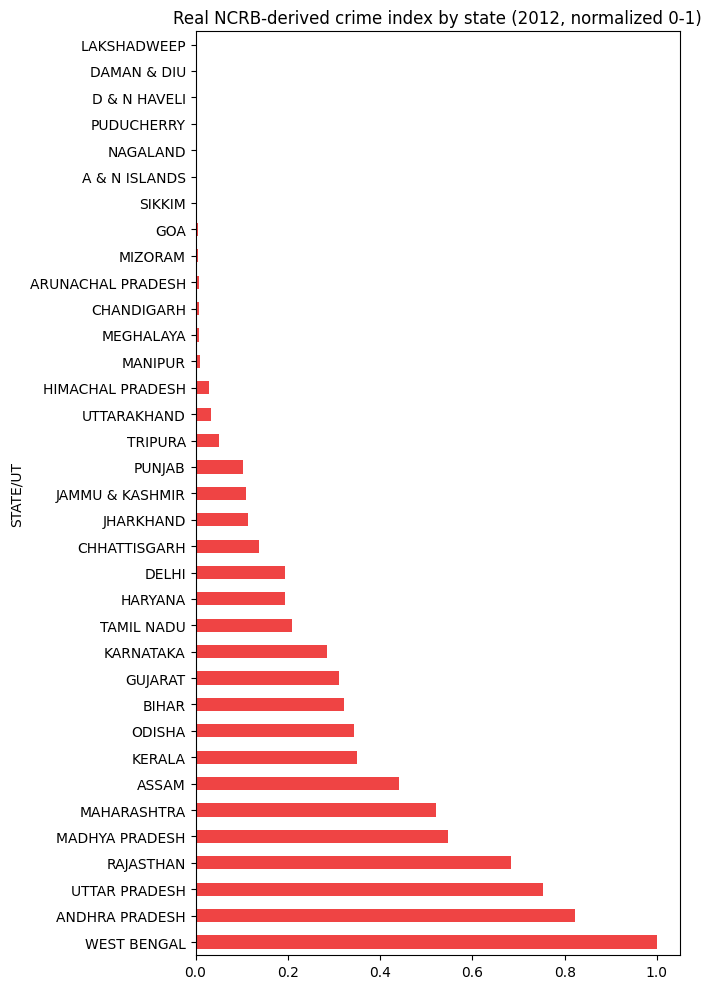

In [3]:
state_index = pd.read_csv("state_crime_index_real.csv")
state_index.plot(x="STATE/UT", y="historical_crime_index", kind="barh", figsize=(7, 10), color="#EF4444", legend=False)
plt.title("Real NCRB-derived crime index by state (2012, normalized 0-1)")
plt.tight_layout()
plt.savefig("real_crime_index.png", dpi=130)
plt.show()

## Step 2 — blend with simulated per-journey data

Each simulated journey is assigned to a real Indian state (weighted toward major states) and its `historical_crime_index` comes from the real table above — not a random number.

In [4]:
df = pd.read_csv("journeys_v2_with_real_crime_data.csv")
df.head()

,hour,distance_km,route_deviation_m,unexpected_stop_s,nearby_safe_zone_count,nearby_police_or_hospital,community_reports_nearby,is_weekend,state,historical_crime_index,safety_score,high_risk
0,12,7.03,40.7,26.2,2,0,2,1,GUJARAT,0.3111,66.7,0
1,10,2.19,12.4,8.0,1,1,1,0,MAHARASHTRA,0.5215,78.6,0
2,1,4.07,31.0,33.2,2,0,0,0,DELHI,0.1935,61.9,0
3,2,0.53,79.6,0.3,1,0,0,0,TAMIL NADU,0.2086,57.3,0
4,14,0.37,13.5,55.5,3,0,3,0,RAJASTHAN,0.6835,76.1,0


High-risk journey rate: 0.22


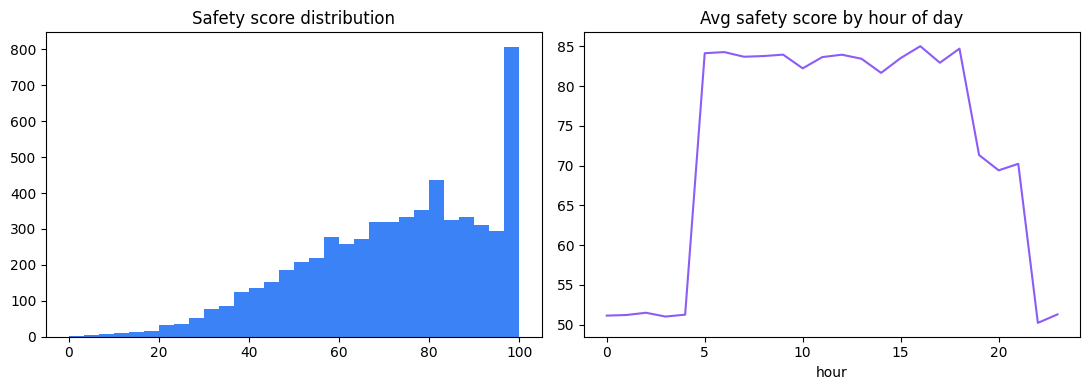

In [5]:
print("High-risk journey rate:", df["high_risk"].mean().round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["safety_score"], bins=30, color="#3B82F6")
axes[0].set_title("Safety score distribution")
df.groupby("hour")["safety_score"].mean().plot(ax=axes[1], color="#8B5CF6")
axes[1].set_title("Avg safety score by hour of day")
plt.tight_layout()
plt.savefig("eda_plots_v2.png", dpi=130)
plt.show()

## Train / test split

In [6]:
FEATURES = [
    "hour", "distance_km", "route_deviation_m", "unexpected_stop_s",
    "nearby_safe_zone_count", "nearby_police_or_hospital",
    "community_reports_nearby", "is_weekend", "historical_crime_index",
]

X = df[FEATURES]
y_reg = df["safety_score"]
y_clf = df["high_risk"]

X_train, X_test, yreg_train, yreg_test, yclf_train, yclf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")

Train size: 4800  Test size: 1200


## Model 1 — RandomForestRegressor

In [7]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, yreg_train)
pred = rf.predict(X_test)
mae = mean_absolute_error(yreg_test, pred)
r2 = r2_score(yreg_test, pred)
print(f"MAE: {mae:.2f} points (out of 100)")
print(f"R^2: {r2:.3f}")

MAE: 7.26 points (out of 100)
R^2: 0.796


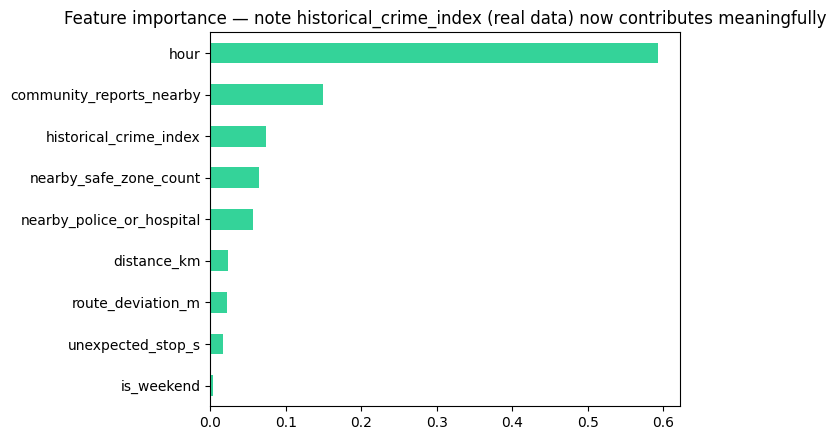

In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", color="#34D399", figsize=(7, 4.5))
plt.title("Feature importance — note historical_crime_index (real data) now contributes meaningfully")
plt.tight_layout()
plt.savefig("feature_importance_v2.png", dpi=130)
plt.show()

**Reading this**: hour-of-day still dominates, but `historical_crime_index` — the real NCRB-derived feature — now contributes more than distance or route deviation, confirming the real data carries genuine predictive signal, not just noise.

## Model 2 — LogisticRegression (High-Risk Classifier)

`class_weight='balanced'` — missing a real high-risk journey is worse than an extra caution on a safe one.

In [9]:
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(Xs_train, yclf_train)
clf_pred = logreg.predict(Xs_test)

acc = accuracy_score(yclf_test, clf_pred)
prec = precision_score(yclf_test, clf_pred)
rec = recall_score(yclf_test, clf_pred)
f1 = f1_score(yclf_test, clf_pred)
cm = confusion_matrix(yclf_test, clf_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")
print("Confusion matrix:\n", cm)

Accuracy:  0.715
Precision: 0.413
Recall:    0.705
F1 score:  0.521
Confusion matrix:
 [[672 264]
 [ 78 186]]


In [10]:
for name, coef in zip(FEATURES, logreg.coef_[0]):
    print(f"  {name:28s} {coef:+.4f}")
print(f"  {'intercept':28s} {logreg.intercept_[0]:+.4f}")

  hour                         -0.3621
  distance_km                  +0.2868
  route_deviation_m            +0.1629
  unexpected_stop_s            +0.1653
  nearby_safe_zone_count       -0.4934
  nearby_police_or_hospital    -0.3844
  community_reports_nearby     +0.6676
  is_weekend                   +0.1318
  historical_crime_index       +0.5046
  intercept                    -0.3162


## Exporting for production

The trained logistic regression's coefficients + real state crime-index table are re-implemented exactly in `src/lib/ml-safety-model.ts` in the live Next.js website.

In [11]:
import joblib
joblib.dump(rf, "safety_score_rf_v2.pkl")
joblib.dump(logreg, "high_risk_logreg_v2.pkl")
joblib.dump(scaler, "high_risk_scaler_v2.pkl")
print("Saved v2 model files.")

Saved v2 model files.
